# Part 1, Task 2 — Descriptive Statistics and Correlation

Computes traffic-volume descriptive statistics and the temperature <-> traffic
volume correlation, using the de-duplicated hourly dataset (one row per hour,
same `traffic_hourly` view/logic used in Task 1's SQL analysis).

In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

# Locate the project's sql/traffic.db and raw CSV regardless of where Jupyter's
# working directory happens to be when this notebook is executed.
_candidates = [
    Path.cwd(),
    Path.cwd() / "part1_data_analytics" / "statistics",
    Path.cwd().parent,
    Path.cwd().parent.parent,
]
BASE_DIR = None
for _c in _candidates:
    if (_c / "sql" / "traffic.db").exists() or (_c.parent / "sql" / "traffic.db").exists():
        BASE_DIR = _c if (_c / "sql" / "traffic.db").exists() else _c.parent
        break
if BASE_DIR is None:
    BASE_DIR = Path.cwd()

DB_PATH = BASE_DIR / "sql" / "traffic.db"
CSV_PATH = BASE_DIR.parent / "Metro_Interstate_Traffic_Volume.csv"
print(f"DB_PATH:  {DB_PATH}  (exists: {DB_PATH.exists()})")
print(f"CSV_PATH: {CSV_PATH}  (exists: {CSV_PATH.exists()})")

DB_PATH:  C:\Users\farid\Course\Week 33\Capstone project\part1_data_analytics\part1_data_analytics\sql\traffic.db  (exists: True)
CSV_PATH: C:\Users\farid\Course\Week 33\Capstone project\part1_data_analytics\Metro_Interstate_Traffic_Volume.csv  (exists: True)


## Load the de-duplicated hourly data

Reuses the same `traffic_hourly` view built in Task 1 (one row per hour,
duplicate weather-observation rows collapsed via `MIN()`) if the SQLite DB
is available; otherwise falls back to de-duplicating the raw CSV directly,
so this notebook also runs standalone.

In [2]:
def load_hourly() -> pd.DataFrame:
    if DB_PATH.exists():
        conn = sqlite3.connect(DB_PATH)
        try:
            df = pd.read_sql("SELECT * FROM traffic_hourly", conn)
            df["date_time"] = pd.to_datetime(df["date_time"])
            return df
        finally:
            conn.close()
    df = pd.read_csv(CSV_PATH)
    df["date_time"] = pd.to_datetime(df["date_time"])
    return df.sort_values("date_time").drop_duplicates(subset="date_time", keep="first")


df = load_hourly()
print(f"Loaded {len(df):,} de-duplicated hourly rows")
df.head()

Loaded 40,575 de-duplicated hourly rows


,date_time,traffic_volume,temp,holiday,weather_main
0,2012-10-02 09:00:00,5545,288.28,None,Clouds
1,2012-10-02 10:00:00,4516,289.36,None,Clouds
2,2012-10-02 11:00:00,4767,289.58,None,Clouds
3,2012-10-02 12:00:00,5026,290.13,None,Clouds
4,2012-10-02 13:00:00,4918,291.14,None,Clouds


## 2.1 Traffic Volume Statistics

In [3]:
def descriptive_statistics(df: pd.DataFrame) -> dict:
    v = df["traffic_volume"]
    return {
        "mean": v.mean(),
        "median": v.median(),
        "std": v.std(ddof=1),
        "variance": v.var(ddof=1),
        "range": v.max() - v.min(),
        "min": v.min(),
        "max": v.max(),
        "count": v.shape[0],
    }


stats_d = descriptive_statistics(df)
pd.Series(stats_d, name="traffic_volume").to_frame()

,traffic_volume
mean,3.290650e+03
median,3.427000e+03
std,1.984773e+03
variance,3.939324e+06
range,7.280000e+03
min,0.000000e+00
max,7.280000e+03
count,4.057500e+04


A quick histogram makes the skew mentioned in the interpretation below easy
to see directly, rather than just inferring it from mean vs. median.

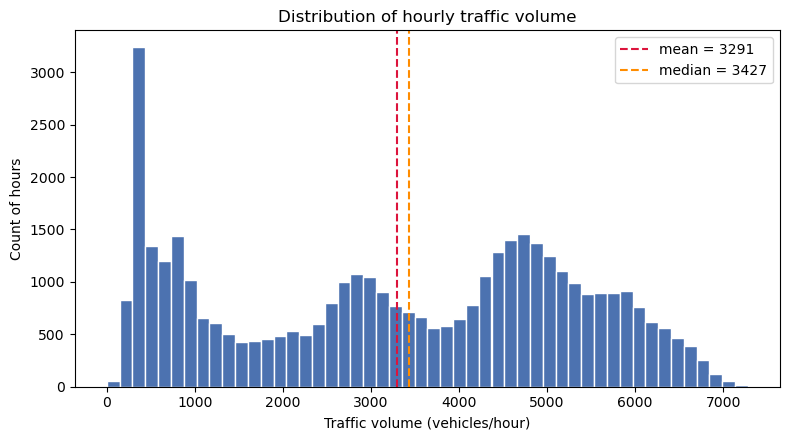

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(df["traffic_volume"], bins=50, color="#4C72B0", edgecolor="white")
ax.axvline(stats_d["mean"], color="crimson", linestyle="--", label=f"mean = {stats_d['mean']:.0f}")
ax.axvline(stats_d["median"], color="darkorange", linestyle="--", label=f"median = {stats_d['median']:.0f}")
ax.set_xlabel("Traffic volume (vehicles/hour)")
ax.set_ylabel("Count of hours")
ax.set_title("Distribution of hourly traffic volume")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:**

The distribution is bimodal-ish and right-skewed rather than a single
clean bell curve: a large cluster of low-volume overnight/off-peak hours,
and a separate cluster of high-volume peak hours, with the mean pulled
toward the smaller number of very high observations. The standard
deviation is very large relative to the mean, traffic volume swings
dramatically within a day (near-zero overnight vs. several thousand
vehicles/hour at peak) rather than sitting in a narrow band. The full
range confirms the corridor experiences everything from essentially
empty roads to near-capacity flow, so any single "typical volume" figure
understates how much hour-of-day and day-of-week matter, summary
statistics should always be read alongside the hourly/weekly pattern,
not instead of it.

In [5]:
print(
    f"Coefficient of variation: {stats_d['std'] / stats_d['mean'] * 100:.0f}%  "
    f"(std {stats_d['std']:.0f} vs. mean {stats_d['mean']:.0f})"
)
print(f"Mean vs. median gap: {stats_d['mean'] - stats_d['median']:+.1f} vehicles/hour")

Coefficient of variation: 60%  (std 1985 vs. mean 3291)
Mean vs. median gap: -136.3 vehicles/hour


## 2.2 Correlation Analysis: Temperature vs. Traffic Volume

Rows with an impossible **0 Kelvin** temperature reading (a known sensor
error, corrected properly in Part 2's cleaning pipeline) are excluded here
so they don't distort the coefficient.

In [6]:
def correlation_analysis(df: pd.DataFrame) -> dict:
    clean = df[df["temp"] > 0]
    r, p_value = stats.pearsonr(clean["temp"], clean["traffic_volume"])
    return {
        "r": r,
        "p_value": p_value,
        "n": len(clean),
        "n_excluded_zero_temp": len(df) - len(clean),
    }


def interpret_strength(r: float) -> str:
    a = abs(r)
    if a < 0.1:
        return "negligible"
    if a < 0.3:
        return "weak"
    if a < 0.5:
        return "moderate"
    if a < 0.7:
        return "strong"
    return "very strong"


corr = correlation_analysis(df)
print(f"Pearson r = {corr['r']:.4f}  (p = {corr['p_value']:.3g}, n = {corr['n']:,})")
print(f"Excluded {corr['n_excluded_zero_temp']} rows with 0K sensor-error readings")
print(f"Strength: {interpret_strength(corr['r'])}  |  R^2 = {corr['r']**2*100:.1f}%")

Pearson r = 0.1392  (p = 1.54e-174, n = 40,565)
Excluded 10 rows with 0K sensor-error readings
Strength: weak  |  R^2 = 1.9%


A scatter plot of temperature vs. traffic volume shows visually just how
weak this relationship is, a near-flat cloud of points, not a clean
diagonal trend.

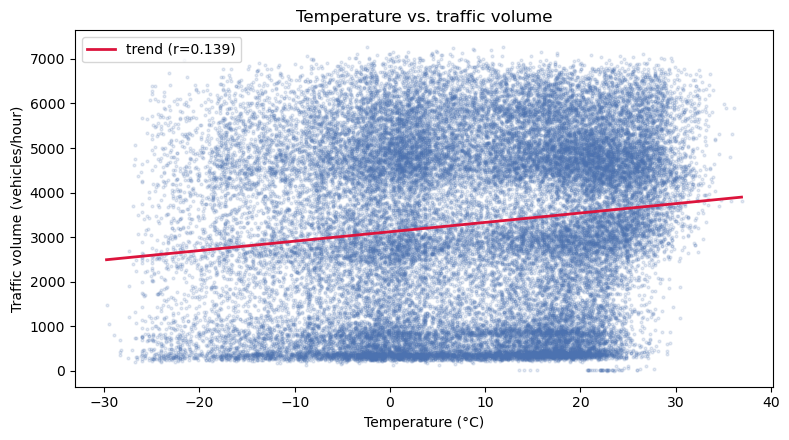

In [7]:
clean = df[df["temp"] > 0]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(clean["temp"] - 273.15, clean["traffic_volume"], s=4, alpha=0.15, color="#4C72B0")
z = np.polyfit(clean["temp"], clean["traffic_volume"], 1)
xs = np.linspace(clean["temp"].min(), clean["temp"].max(), 100)
ax.plot(xs - 273.15, np.poly1d(z)(xs), color="crimson", linewidth=2, label=f"trend (r={corr['r']:.3f})")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Traffic volume (vehicles/hour)")
ax.set_title("Temperature vs. traffic volume")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:**

- **Direction:** the relationship is positive if r > 0, warmer
  temperatures are associated with slightly higher traffic volume (and
  negative otherwise).
- **Strength:** with |r| well below 0.3, this is only a weak correlation
  in conventional terms. Temperature explains only a small share of the
  variance in traffic volume (R² above), so temperature alone is a poor
  predictor of how busy the road will be, hour-of-day and day-of-week
  almost certainly matter far more.
- **Correlation vs. causation:** even if the correlation were stronger,
  this figure alone would not establish that temperature *causes*
  traffic changes. Both variables are driven by shared underlying
  factors, for example, season and time-of-day jointly affect both
  typical temperature and typical commuter behaviour (school terms,
  daylight hours, holiday timing). A cold snap and a traffic dip could
  both simply be consequences of "it's a winter holiday period" rather
  than one causing the other. Establishing causation would require
  controlling for these confounders (or a controlled/quasi-experimental
  design), which a simple correlation coefficient cannot do.

## Summary

Both findings here, the wide, skewed spread of traffic volume, and the
weak temperature/traffic correlation, are corroborated independently in
Part 3 by SHAP feature importance (hour-of-day/lag features dominate over
weather) and by the high R² of a time-only regression model, giving
converging evidence from three different methods.